# Tópicos Especiais em Sistema Computacionais II - 2026.1
## **Projeto 02 - Regressão Logística**
Autores: José Cláudio Alves Sobrinho e Ingridy Duarte Costa



## INTRODUÇÃO E CONTEXTO

Doenças cardiovasculares são a principal causa de morte no mundo, responsáveis por cerca de 18 milhões de óbitos por ano segundo a OMS. O diagnóstico precoce é determinante para o sucesso do tratamento. Existe, portanto, uma necessidade real de ferramentas capazes de estimar o risco de um paciente com base em dados clínicos simples, coletados em consulta de rotina. É nesse contexto que o aprendizado de máquina pode contribuir. Um modelo de classificação treinado com dados históricos de pacientes diagnosticados é capaz de aprender quais combinações de variáveis clínicas estão associadas à presença de doença cardíaca e aplicar esse aprendizado a novos pacientes.

Neste projeto, você é convidado a construir um modelo utilizando regressão logística para prever a presença de doença cardíaca com base em um conjunto de dados clínicos.

## Preparação do Ambiente

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carregamento dos dados (Exemplo com o dataset de Cleveland)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv(url, names=columns, na_values="?")

## 1 - No Pré-processamento
**(a)** Realize o tratamento de valores nulos (verificar especialmente as colunas ca e thal). Caso existam, escolha o método de imputação através da mediana.

In [ ]:
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

**(b)** Obtenha a binarização da variável target, transformando os valores originais (0 a 4) em uma variável binária (0 = sem doença, 1 = com doença).

In [ ]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

**(c)** Realize a divisão treino/teste com proporção de 80/20, usando stratify=y para preservar o balanceamento entre as classes.

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

**(d)** Faça o escalonamento das features numéricas contínuas (age, trestbps, chol, thalach, oldpeak) com StandardScaler.

In [ ]:
scaler = StandardScaler()
cols_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Ajustamos o scaler apenas no treino para evitar data leakage
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Visualização rápida do resultado
print(f"Formato do treino: {X_train.shape}")
print(f"Distribuição das classes no teste:\n{y_test.value_counts(normalize=True)}")

Formato do treino: (242, 13)
Distribuição das classes no teste:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## 2 - Treinar um modelo de LogisticRegression do scikit-learn utilizando os dados de treino, com os seguintes parâmetros: solver='liblinear', random_state=42 e max_iter=1000. Indique quantas iterações foram necessárias para a convergência do modelo.

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Configurando o modelo com os parâmetros exatos da imagem
modelo_lr = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

# 2. Treinando o modelo
modelo_lr.fit(X_train, y_train)

# 3. Obtendo o número de iterações para a convergência
# Note que n_iter_ retorna um array, então pegamos o primeiro elemento [0]
print(f"Iterações necessárias para convergência: {modelo_lr.n_iter_[0]}")

Iterações necessárias para convergência: 5


##3 Avaliar o modelo utilizando os dados de teste e calcular as seguintes métricas:

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, RocCurveDisplay)
import matplotlib.pyplot as plt

# 1. Gerar previsões e probabilidades
y_pred = modelo_lr.predict(X_test)
y_probs = modelo_lr.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva (1)

**(a)** Acurácia

In [ ]:
print(f" (a) Acurácia: {accuracy_score(y_test, y_pred):.4f}")

 (a) Acurácia: 0.8689


**(b)** Precisão

In [ ]:
print(f" (b) Precisão: {precision_score(y_test, y_pred):.4f}")

 (b) Precisão: 0.8125


**(c)** Recall

In [ ]:
print(f" (c) Recall:    {recall_score(y_test, y_pred):.4f}")

 (c) Recall:    0.9286


**(d)** F1-score

In [ ]:
print(f" (d) F1-score:  {f1_score(y_test, y_pred):.4f}")

 (d) F1-score:  0.8667


**(e)** Curva ROC com valor de AUC

 (e) AUC:       0.9545


<Figure size 800x600 with 0 Axes>

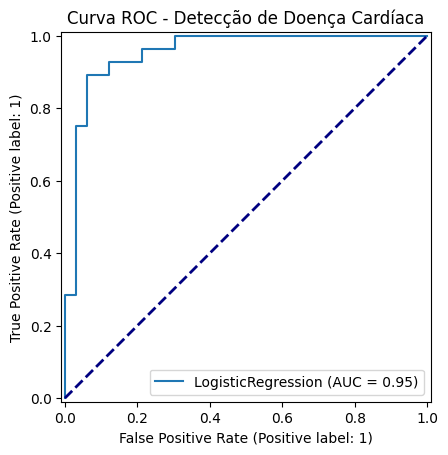

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print(f" (e) AUC:       {roc_auc:.4f}")

# Plotando a curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(modelo_lr, X_test, y_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Curva ROC - Detecção de Doença Cardíaca')
plt.show()